In [1]:
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

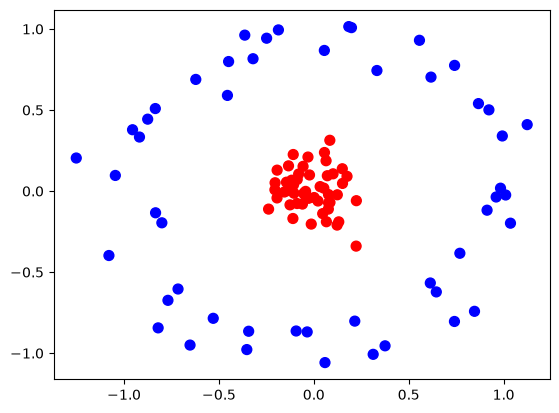

In [2]:
from sklearn.datasets import make_circles
X,Y = make_circles(100,factor=.1,noise=.1)
plt.scatter(X[:,0],X[:,1],c=Y,s=50,cmap='bwr')

In [3]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,0)

In [4]:
classifier = SVC(kernel='linear')
classifier.fit(X_train,Y_train.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
Y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.5

In [17]:
zero_one_colormap = ListedColormap(('blue','red'))
def plot_decision_boundary(X,Y,clf):
    X_set,Y_set = X,Y
    X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-1,stop=X_set[:,0].max() + 1,step=0.01),
                        np.arange(start=X_set[:,1].min()-1,stop=X_set[:,1].max() + 1,step=0.01))

    Z = clf.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape)
    plt.contourf(X1,X2,Z,alpha=0.75,cmap=zero_one_colormap)
    plt.xlim(X1.min(),X1.max())
    plt.ylim(X2.min(),X2.max())
    for i,j in enumerate(np.unique(Y_set)):
        plt.scatter(X_set[Y_set==j,0],X_set[Y_set==j,1],color=(zero_one_colormap)(i),label=j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.xlabel('X2')
    plt.legend()
    return plt.show()

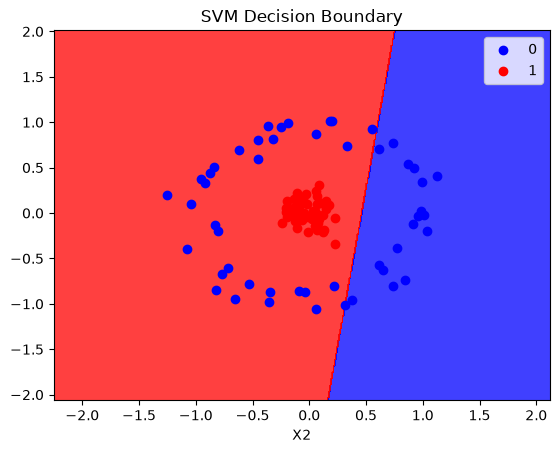

In [18]:
plot_decision_boundary(X,Y,classifier)

In [11]:
def plot_3d_plot(X,Y):
    #r ~ z-coordinate (r uses radial basis function)
    r = np.exp(-(X**2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:,0],X[:,1],r,c=Y,s=100,cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='X3'>

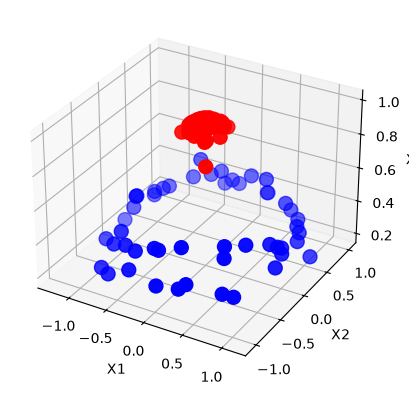

In [12]:
plot_3d_plot(X,Y)

In [13]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train,Y_train)
Y_pred = rbf_classifier.predict(X_test)

In [14]:
accuracy_score(Y_test,Y_pred)

1.0

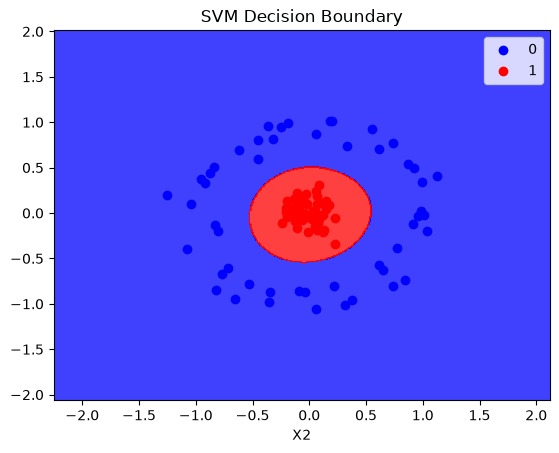

In [19]:
plot_decision_boundary(X,Y,rbf_classifier)

In [30]:
poly_classifier = SVC(kernel='poly')
poly_classifier.fit(X_train,Y_train)
Y_pred = poly_classifier.predict(X_test)

In [31]:
accuracy_score(Y_test,Y_pred)

0.45

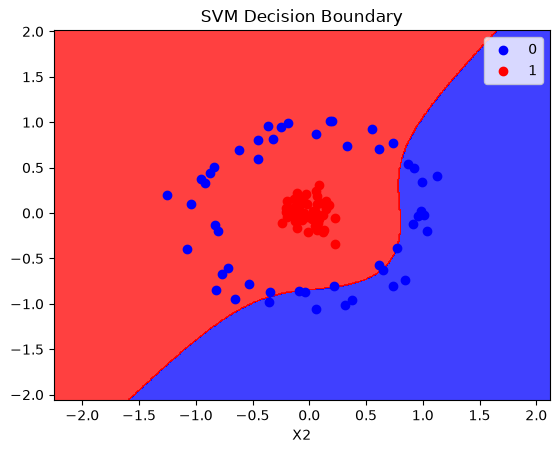

In [32]:
plot_decision_boundary(X,Y,poly_classifier)